## 1. Ucitavanje biblioteka

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from sklearn.decomposition import PCA

import joblib
import os

## 2. Ucitavanje svih izvora podataka

In [3]:
df_train = pd.read_csv('raw_data/application_train.csv')
df_test = pd.read_csv('raw_data/application_test.csv')
print(f"Trening: {df_train.shape}, Test: {df_test.shape}")

bureau = pd.read_csv('raw_data/bureau.csv')
bureau_balance = pd.read_csv('raw_data/bureau_balance.csv')
print(f"Bureau: {bureau.shape}, Bureau Balance: {bureau_balance.shape}")

prev_app = pd.read_csv('raw_data/previous_application.csv')
print(f"Prethodne prijave: {prev_app.shape}")

pos_cash = pd.read_csv('raw_data/POS_CASH_balance.csv')
credit_card = pd.read_csv('raw_data/credit_card_balance.csv')
print(f"POS Cash: {pos_cash.shape}, Kreditne kartice: {credit_card.shape}")

installments = pd.read_csv('raw_data/installments_payments.csv')
print(f"Rate: {installments.shape}")

Trening: (307511, 122), Test: (48744, 121)
Bureau: (1716428, 17), Bureau Balance: (27299925, 3)
Prethodne prijave: (1670214, 37)
POS Cash: (10001358, 8), Kreditne kartice: (3840312, 23)
Rate: (13605401, 8)


## 4. Obrada Bureau podataka

In [4]:
print("Obrada Bureau podataka...")

# Agregacija bureau_balance po SK_ID_BUREAU
bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'mean', 'count'],
    'STATUS': lambda x: (x == 'C').sum()  # Broj zatvorenih meseci
}).reset_index()

bureau_balance_agg.columns = ['SK_ID_BUREAU', 'BB_MONTHS_MIN', 'BB_MONTHS_MAX', 
                               'BB_MONTHS_MEAN', 'BB_MONTHS_COUNT', 'BB_STATUS_CLOSED']

# Spajanje sa bureau tabelom
bureau = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')
del bureau_balance_agg
gc.collect()

print(f"Bureau nakon spajanja: {bureau.shape}")

Obrada Bureau podataka...
Bureau nakon spajanja: (1716428, 22)


In [5]:
# Agregacija bureau po SK_ID_CURR (ID klijenta)
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',
    'DAYS_CREDIT': ['min', 'max', 'mean'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean', 'sum'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],
    'CNT_CREDIT_PROLONG': 'sum',
    'AMT_CREDIT_SUM': ['sum', 'mean', 'max'],
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean', 'max'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum', 'mean'],
    'DAYS_CREDIT_UPDATE': ['min', 'max', 'mean'],
    'AMT_ANNUITY': ['sum', 'mean', 'max'],
    'BB_MONTHS_COUNT': ['sum', 'mean'],
    'BB_STATUS_CLOSED': ['sum', 'mean']
}).reset_index()

# Spajanje naziva kolona
bureau_agg.columns = ['SK_ID_CURR'] + ['BUREAU_' + '_'.join(col).strip() for col in bureau_agg.columns[1:]]

# Izvedeni atributi
bureau_agg['BUREAU_DEBT_RATIO'] = bureau_agg['BUREAU_AMT_CREDIT_SUM_DEBT_sum'] / (bureau_agg['BUREAU_AMT_CREDIT_SUM_sum'] + 1)
bureau_agg['BUREAU_OVERDUE_RATIO'] = bureau_agg['BUREAU_AMT_CREDIT_SUM_OVERDUE_sum'] / (bureau_agg['BUREAU_AMT_CREDIT_SUM_sum'] + 1)

print(f"Bureau agregirano: {bureau_agg.shape}")
print(f"Bureau atributi: {list(bureau_agg.columns[:10])}...")

del bureau, bureau_balance
gc.collect()

Bureau agregirano: (305811, 34)
Bureau atributi: ['SK_ID_CURR', 'BUREAU_SK_ID_BUREAU_count', 'BUREAU_DAYS_CREDIT_min', 'BUREAU_DAYS_CREDIT_max', 'BUREAU_DAYS_CREDIT_mean', 'BUREAU_CREDIT_DAY_OVERDUE_max', 'BUREAU_CREDIT_DAY_OVERDUE_mean', 'BUREAU_CREDIT_DAY_OVERDUE_sum', 'BUREAU_DAYS_CREDIT_ENDDATE_min', 'BUREAU_DAYS_CREDIT_ENDDATE_max']...


0

## 5. Obrada prethodnih prijava

In [6]:
print("Obrada prethodnih prijava...")

# Zamena anomalnih vrednosti
prev_app['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_LAST_DUE'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_TERMINATION'].replace(365243, np.nan, inplace=True)

# Racunanje odnosa vrednosti prijave
prev_app['APP_CREDIT_PERC'] = prev_app['AMT_APPLICATION'] / (prev_app['AMT_CREDIT'] + 1)

# Agregacija po SK_ID_CURR
prev_app_agg = prev_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_ANNUITY': ['min', 'max', 'mean', 'sum'],
    'AMT_APPLICATION': ['min', 'max', 'mean', 'sum'],
    'AMT_CREDIT': ['min', 'max', 'mean', 'sum'],
    'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
    'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
    'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'DAYS_DECISION': ['min', 'max', 'mean'],
    'CNT_PAYMENT': ['mean', 'sum'],
    'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var']
}).reset_index()

# Spajanje naziva kolona
prev_app_agg.columns = ['SK_ID_CURR'] + ['PREV_' + '_'.join(col).strip() for col in prev_app_agg.columns[1:]]

# Brojanje odobrenih/odbijenih prijava
approved = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size()
refused = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Refused'].groupby('SK_ID_CURR').size()

prev_app_agg = prev_app_agg.merge(
    approved.reset_index().rename(columns={0: 'PREV_APPROVED_COUNT'}), 
    on='SK_ID_CURR', how='left'
)
prev_app_agg = prev_app_agg.merge(
    refused.reset_index().rename(columns={0: 'PREV_REFUSED_COUNT'}), 
    on='SK_ID_CURR', how='left'
)

prev_app_agg['PREV_APPROVED_COUNT'] = prev_app_agg['PREV_APPROVED_COUNT'].fillna(0)
prev_app_agg['PREV_REFUSED_COUNT'] = prev_app_agg['PREV_REFUSED_COUNT'].fillna(0)
prev_app_agg['PREV_APPROVAL_RATE'] = prev_app_agg['PREV_APPROVED_COUNT'] / (prev_app_agg['PREV_SK_ID_PREV_count'] + 1)

print(f"Prethodne prijave agregirane: {prev_app_agg.shape}")

del prev_app
gc.collect()

Obrada prethodnih prijava...
Prethodne prijave agregirane: (338857, 38)


0

## 6. Obrada POS Cash podataka

In [7]:
print("Obrada POS Cash podataka...")

# Agregacija po SK_ID_CURR
pos_cash_agg = pos_cash.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['min', 'max', 'mean', 'count'],
    'CNT_INSTALMENT': ['min', 'max', 'mean'],
    'CNT_INSTALMENT_FUTURE': ['min', 'max', 'mean'],
    'SK_DPD': ['max', 'mean', 'sum'],
    'SK_DPD_DEF': ['max', 'mean', 'sum']
}).reset_index()

# Spajanje naziva kolona
pos_cash_agg.columns = ['SK_ID_CURR'] + ['POS_' + '_'.join(col).strip() for col in pos_cash_agg.columns[1:]]

# Brojanje kasnjenja u placanju
pos_late = pos_cash[pos_cash['SK_DPD'] > 0].groupby('SK_ID_CURR').size().reset_index(name='POS_LATE_PAYMENTS')
pos_cash_agg = pos_cash_agg.merge(pos_late, on='SK_ID_CURR', how='left')
pos_cash_agg['POS_LATE_PAYMENTS'] = pos_cash_agg['POS_LATE_PAYMENTS'].fillna(0)

print(f"POS Cash agregirano: {pos_cash_agg.shape}")

del pos_cash
gc.collect()

Obrada POS Cash podataka...
POS Cash agregirano: (337252, 18)


0

## 7. Obrada podataka kreditnih kartica

In [8]:
print("Obrada podataka kreditnih kartica...")

# Agregacija po SK_ID_CURR
cc_agg = credit_card.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['min', 'max', 'mean', 'count'],
    'AMT_BALANCE': ['min', 'max', 'mean'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['min', 'max', 'mean'],
    'AMT_DRAWINGS_ATM_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_DRAWINGS_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_INST_MIN_REGULARITY': ['min', 'max', 'mean'],
    'AMT_PAYMENT_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_PAYMENT_TOTAL_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_TOTAL_RECEIVABLE': ['min', 'max', 'mean'],
    'CNT_DRAWINGS_ATM_CURRENT': ['min', 'max', 'mean', 'sum'],
    'CNT_DRAWINGS_CURRENT': ['min', 'max', 'mean', 'sum'],
    'SK_DPD': ['max', 'mean', 'sum'],
    'SK_DPD_DEF': ['max', 'mean', 'sum']
}).reset_index()

# Spajanje naziva kolona
cc_agg.columns = ['SK_ID_CURR'] + ['CC_' + '_'.join(col).strip() for col in cc_agg.columns[1:]]

# Racunanje stope iskoriscenosti
cc_agg['CC_UTILIZATION_RATE'] = cc_agg['CC_AMT_BALANCE_mean'] / (cc_agg['CC_AMT_CREDIT_LIMIT_ACTUAL_mean'] + 1)

print(f"Kreditne kartice agregirano: {cc_agg.shape}")

del credit_card
gc.collect()

Obrada podataka kreditnih kartica...
Kreditne kartice agregirano: (103558, 48)


0

## 8. Obrada podataka o ratama

In [9]:
print("Obrada podataka o ratama...")

# Racunanje atributa ponasanja pri placanju
installments['PAYMENT_DIFF'] = installments['AMT_PAYMENT'] - installments['AMT_INSTALMENT']
installments['PAYMENT_RATIO'] = installments['AMT_PAYMENT'] / (installments['AMT_INSTALMENT'] + 1)
installments['DAYS_DIFF'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['LATE_PAYMENT'] = (installments['DAYS_DIFF'] > 0).astype(int)

# Agregacija po SK_ID_CURR
inst_agg = installments.groupby('SK_ID_CURR').agg({
    'NUM_INSTALMENT_VERSION': ['max', 'mean'],
    'NUM_INSTALMENT_NUMBER': ['max', 'mean'],
    'DAYS_INSTALMENT': ['min', 'max', 'mean'],
    'DAYS_ENTRY_PAYMENT': ['min', 'max', 'mean'],
    'AMT_INSTALMENT': ['min', 'max', 'mean', 'sum'],
    'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
    'PAYMENT_DIFF': ['min', 'max', 'mean', 'sum'],
    'PAYMENT_RATIO': ['min', 'max', 'mean'],
    'DAYS_DIFF': ['min', 'max', 'mean', 'sum'],
    'LATE_PAYMENT': ['sum', 'mean']
}).reset_index()

# Spajanje naziva kolona
inst_agg.columns = ['SK_ID_CURR'] + ['INST_' + '_'.join(col).strip() for col in inst_agg.columns[1:]]

print(f"Rate agregirane: {inst_agg.shape}")

del installments
gc.collect()

Obrada podataka o ratama...
Rate agregirane: (339587, 32)


0

## 9. Spajanje svih atributa

In [10]:
print("Spajanje svih atributa...")

# Pocetni skup - glavna tabela prijava
df = df_train.copy()
print(f"Osnovna velicina: {df.shape}")

# Spajanje bureau atributa
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
print(f"Nakon Bureau: {df.shape}")

# Spajanje atributa prethodnih prijava
df = df.merge(prev_app_agg, on='SK_ID_CURR', how='left')
print(f"Nakon prethodnih prijava: {df.shape}")

# Spajanje POS Cash atributa
df = df.merge(pos_cash_agg, on='SK_ID_CURR', how='left')
print(f"Nakon POS Cash: {df.shape}")

# Spajanje atributa kreditnih kartica
df = df.merge(cc_agg, on='SK_ID_CURR', how='left')
print(f"Nakon kreditnih kartica: {df.shape}")

# Spajanje atributa rata
df = df.merge(inst_agg, on='SK_ID_CURR', how='left')
print(f"Nakon rata: {df.shape}")

print(f"\nFinalni spojeni skup: {df.shape}")
print(f"Ukupno atributa: {df.shape[1] - 2} (bez SK_ID_CURR i TARGET)")

# Oslobadjanje memorije
del bureau_agg, prev_app_agg, pos_cash_agg, cc_agg, inst_agg
gc.collect()

Spajanje svih atributa...
Osnovna velicina: (307511, 122)
Nakon Bureau: (307511, 155)
Nakon prethodnih prijava: (307511, 192)
Nakon POS Cash: (307511, 209)
Nakon kreditnih kartica: (307511, 256)
Nakon rata: (307511, 287)

Finalni spojeni skup: (307511, 287)
Ukupno atributa: 285 (bez SK_ID_CURR i TARGET)


0

## 10. Inzenjering atributa na glavnim podacima

In [11]:
print("Kreiranje domenskih atributa iz glavne tabele...")

# Odnosi prihoda i kredita
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

# Atributi vezani za starost
df['DAYS_BIRTH_YEARS'] = df['DAYS_BIRTH'] / -365
df['DAYS_EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'] / -365
df['EMPLOYED_TO_BIRTH_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)

# Zamena anomalnih vrednosti za DAYS_EMPLOYED
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Prihod po clanu porodice
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['INCOME_PER_CHILD'] = df['AMT_INCOME_TOTAL'] / (df['CNT_CHILDREN'] + 1)

# Kombinacije spoljnih izvora
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

# Suma flag-ova dokumenata
doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
df['DOCUMENT_COUNT'] = df[doc_cols].sum(axis=1)

# Default-ovi u socijalnom krugu
df['SOCIAL_CIRCLE_DEFAULT'] = df['DEF_30_CNT_SOCIAL_CIRCLE'] + df['DEF_60_CNT_SOCIAL_CIRCLE']

print(f"Oblik nakon domenskih atributa: {df.shape}")

Kreiranje domenskih atributa iz glavne tabele...
Oblik nakon domenskih atributa: (307511, 302)


## 11. Preprocesiranje

In [12]:
print("Preprocesiranje...")

# Cuvanje ID-jeva i ciljne promenljive
ids = df['SK_ID_CURR']
y = df['TARGET']
X = df.drop(['SK_ID_CURR', 'TARGET'], axis=1)

# Identifikacija tipova kolona
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Kategoricke kolone: {len(categorical_cols)}")
print(f"Numericke kolone: {len(numeric_cols)}")

# Enkodiranje kategorickih promenljivih
le = LabelEncoder()
for col in categorical_cols:
    X[col] = X[col].fillna('Missing')
    X[col] = le.fit_transform(X[col].astype(str))

# Popunjavanje nedostajucih numerickih vrednosti medijanom
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Zamena beskonacnih vrednosti
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print(f"\nFinalni preprocesirani oblik: {X.shape}")
print(f"Nedostajuce vrednosti: {X.isnull().sum().sum()}")

Preprocesiranje...
Kategoricke kolone: 16
Numericke kolone: 284

Finalni preprocesirani oblik: (307511, 300)
Nedostajuce vrednosti: 0


In [13]:
# Cuvanje preprocesiranih podataka
os.makedirs('preprocessed_data', exist_ok=True)

preprocessed_advanced = X.copy()
preprocessed_advanced['SK_ID_CURR'] = ids.values
preprocessed_advanced['TARGET'] = y.values
preprocessed_advanced.to_csv('preprocessed_data/application_advanced_preprocessed.csv', index=False)
print(f"Napredni preprocesirani podaci sacuvani: {preprocessed_advanced.shape}")

Napredni preprocesirani podaci sacuvani: (307511, 302)


## 12. 2D/3D vizualizacija

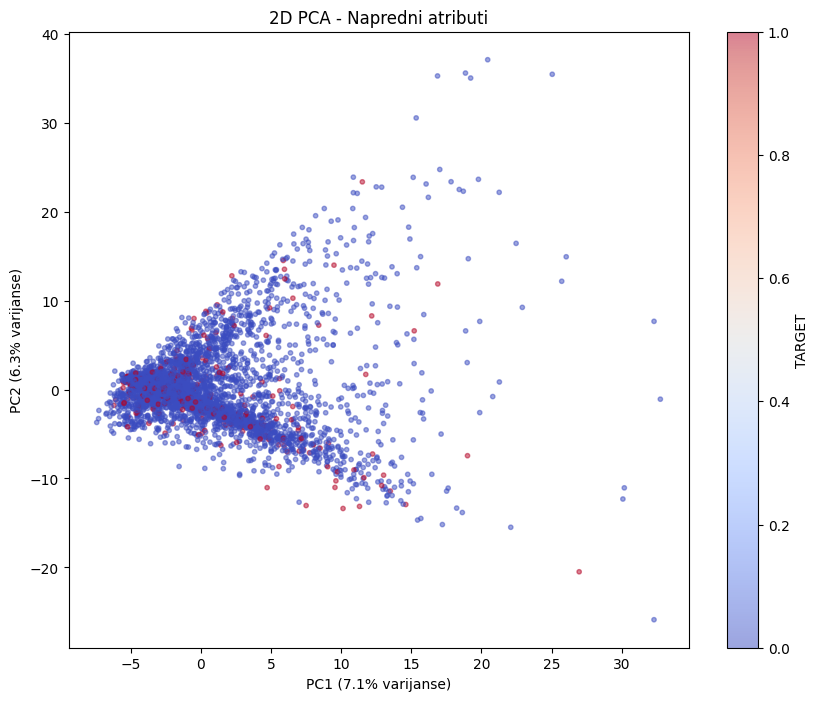

Objasnjene varijanse: 13.4%


In [14]:
# Uzorak za vizualizaciju
np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

# Skaliranje
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_sample)

# 2D PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled_viz)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                     c=y_sample, cmap='coolwarm', alpha=0.5, s=10)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varijanse)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varijanse)')
ax.set_title('2D PCA - Napredni atributi')
plt.colorbar(scatter, label='TARGET')
plt.savefig('pca_2d_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Objasnjene varijanse: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

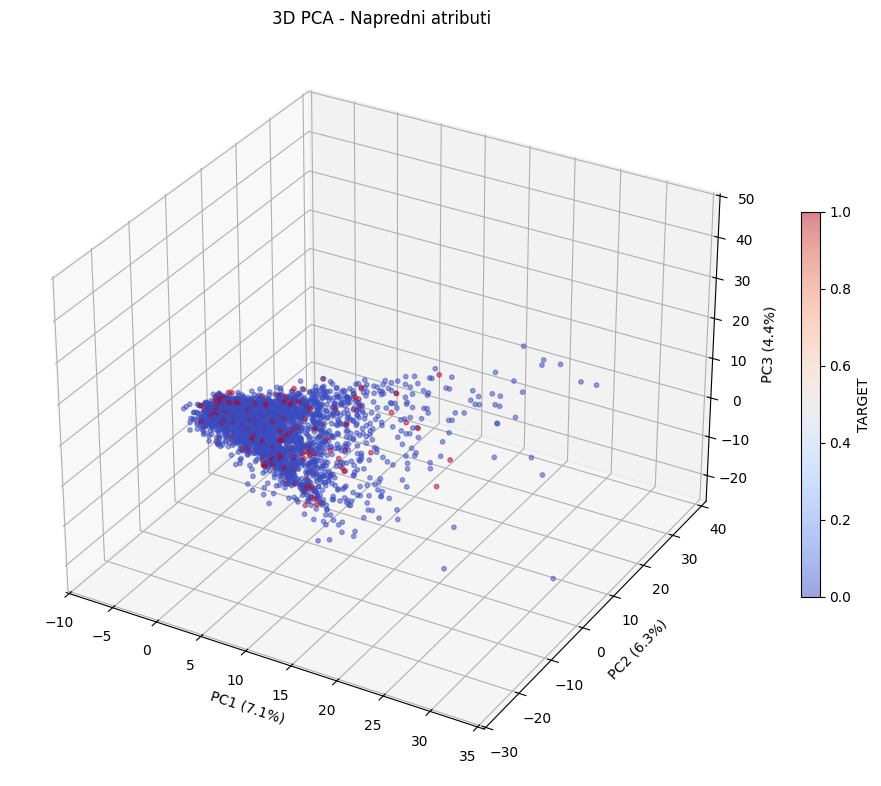

In [15]:
# 3D PCA vizualizacija
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled_viz)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=y_sample, cmap='coolwarm', alpha=0.5, s=10)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('3D PCA - Napredni atributi')
plt.colorbar(scatter, label='TARGET', shrink=0.5)
plt.savefig('pca_3d_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Podela podataka

In [16]:
# Podela podataka
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trening skup: {X_train.shape}")
print(f"Validacioni skup: {X_val.shape}")

# Skaliranje atributa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Cuvanje scaler-a
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler_advanced.joblib')
print("Scaler sacuvan.")

Trening skup: (246008, 300)
Validacioni skup: (61503, 300)
Scaler sacuvan.


## 14. Treniranje modela sa tezinama klasa

In [17]:
# Racunanje tezina klasa za nebalansirane podatke
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Tezine klasa: {class_weight_dict}")

Tezine klasa: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}


In [18]:
# Definisanje modela sa tezinama klasa gde je primenljivo
models = {
    '1. Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    '2. Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    '3. Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, 
                                                n_jobs=-1, class_weight='balanced'),
    '4. Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    '5. K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    '6. Naive Bayes': GaussianNB(),
    '7. AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

print(f"Broj modela: {len(models)}")

Broj modela: 7


In [ ]:
# Treniranje modela
results = []

for name, model in models.items():
    print(f"\nTreniranje {name}...")
    
    # Koristi skalirane podatke za modele bazirane na udaljenosti
    if 'KNN' in name or 'Logistic' in name:
        X_data = X_train_scaled
        X_val_data = X_val_scaled
    else:
        X_data = X_train
        X_val_data = X_val
    
    # Treniranje modela
    model.fit(X_data, y_train)
    
    # Predikcije
    y_pred = model.predict(X_val_data)
    y_pred_proba = model.predict_proba(X_val_data)[:, 1]
    
    # Unakrsna validacija (5 fold-ova)
    cv_scores = cross_val_score(model, X_data, y_train, cv=5, scoring='roc_auc')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Racunanje metrika
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std
    })
    
    # Cuvanje modela
    model_filename = f"models/advanced_{name.replace(' ', '_').replace('.', '')}.joblib"
    joblib.dump(model, model_filename)
    
    print(f"  Tacnost: {accuracy:.4f}")
    print(f"  Odziv: {recall:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")


Treniranje 1. Logistic Regression...
  Tacnost: 0.7059
  Odziv: 0.6957
  ROC-AUC: 0.7704
  CV ROC-AUC: 0.7686 (+/- 0.0038)

Treniranje 2. Decision Tree...
  Tacnost: 0.6724
  Odziv: 0.6421
  ROC-AUC: 0.6941
  CV ROC-AUC: 0.6872 (+/- 0.0088)

Treniranje 3. Random Forest...
  Tacnost: 0.7573
  Odziv: 0.6062
  ROC-AUC: 0.7596
  CV ROC-AUC: 0.7554 (+/- 0.0052)

Treniranje 4. Gradient Boosting...


## 15. Poredjenje modela

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

results_df.to_csv('model_comparison_advanced.csv', index=False)

ADVANCED SOLUTION - MODEL COMPARISON
                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  4. Gradient Boosting  0.919695   0.532020 0.043505  0.080432 0.779842
1. Logistic Regression  0.705917   0.172441 0.695670  0.276375 0.770438
           7. AdaBoost  0.919760   0.615385 0.016113  0.031403 0.766374
      3. Random Forest  0.757280   0.188325 0.606244  0.287378 0.759627
      2. Decision Tree  0.672439   0.147887 0.642095  0.240404 0.694076
        6. Naive Bayes  0.185324   0.084147 0.919839  0.154189 0.611031
5. K-Nearest Neighbors  0.913809   0.158537 0.015710  0.028587 0.549233


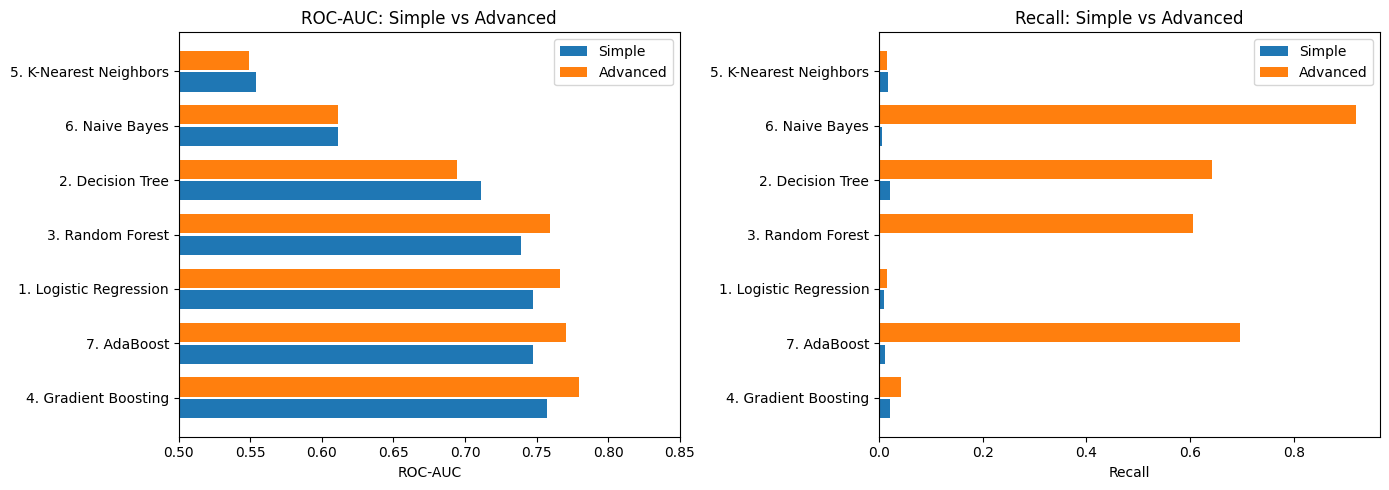

In [ ]:
# Poredjenje sa jednostavnim resenjam
simple_results = pd.read_csv('model_comparison_results.csv')
simple_results['Solution'] = 'Simple'
results_df['Solution'] = 'Advanced'

comparison = pd.concat([simple_results, results_df])

# Grafik poredjenja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC poredjenje
for i, solution in enumerate(['Simple', 'Advanced']):
    data = comparison[comparison['Solution'] == solution]
    bars = axes[0].barh(np.arange(len(data)) + i*0.4, data['ROC-AUC'], 
                        height=0.35, label=solution)
axes[0].set_yticks(np.arange(len(simple_results)) + 0.2)
axes[0].set_yticklabels(simple_results['Model'])
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('ROC-AUC: Jednostavno vs Napredno')
axes[0].legend()
axes[0].set_xlim(0.5, 0.85)

# Recall poredjenje
for i, solution in enumerate(['Simple', 'Advanced']):
    data = comparison[comparison['Solution'] == solution]
    bars = axes[1].barh(np.arange(len(data)) + i*0.4, data['Recall'], 
                        height=0.35, label=solution)
axes[1].set_yticks(np.arange(len(simple_results)) + 0.2)
axes[1].set_yticklabels(simple_results['Model'])
axes[1].set_xlabel('Recall')
axes[1].set_title('Recall: Jednostavno vs Napredno')
axes[1].legend()

plt.tight_layout()
plt.savefig('simple_vs_advanced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

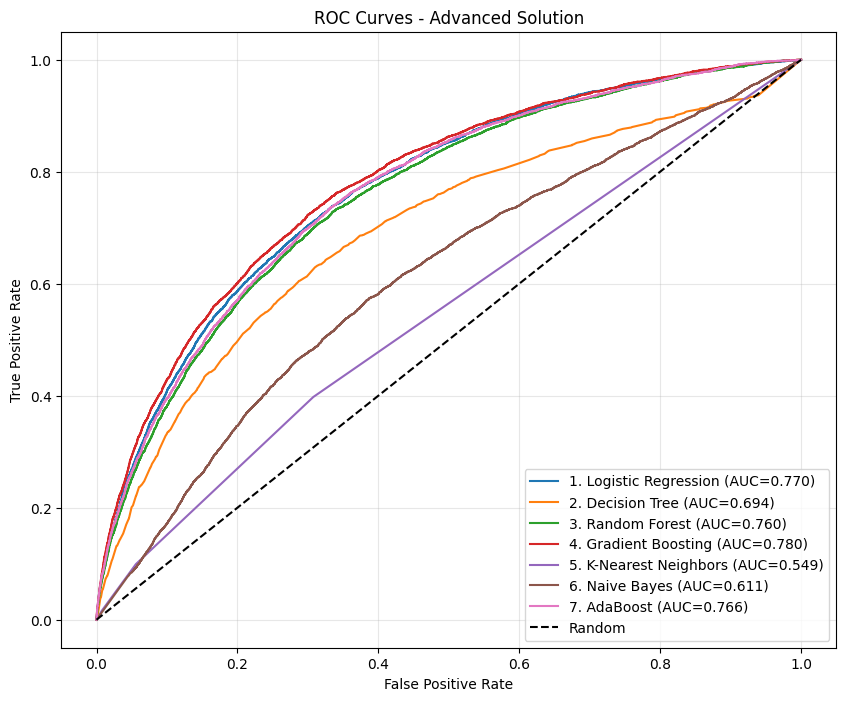

In [ ]:
# ROC krive
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    if 'KNN' in name or 'Logistic' in name:
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Slucajno')
ax.set_xlabel('Stopa lazno pozitivnih (FPR)')
ax.set_ylabel('Stopa stvarno pozitivnih (TPR)')
ax.set_title('ROC krive - Napredno resenje')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.savefig('roc_curves_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

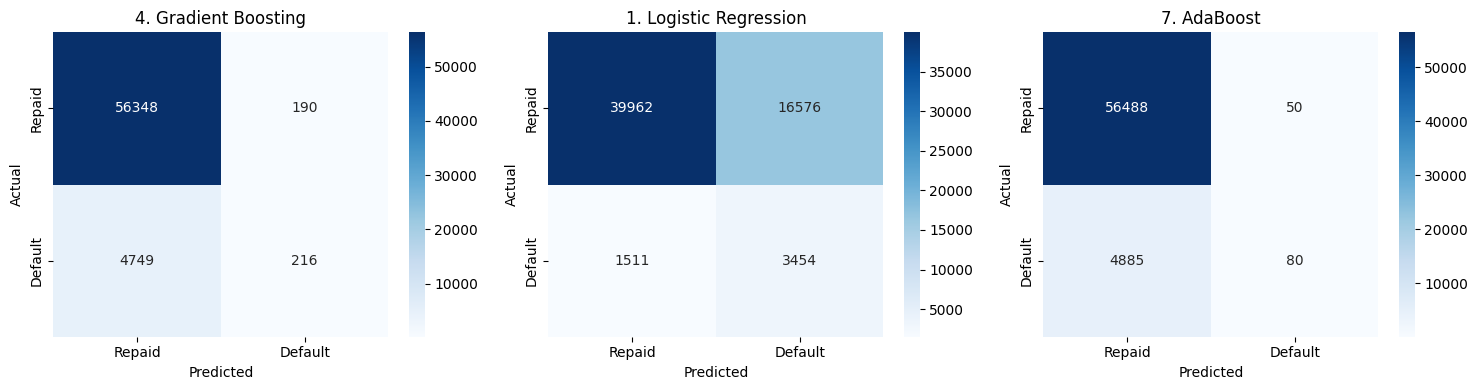

In [ ]:
# Matrice konfuzije za top 3 modela
top_3 = results_df.head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top_3):
    model = models[name]
    
    if 'KNN' in name or 'Logistic' in name:
        y_pred = model.predict(X_val_scaled)
    else:
        y_pred = model.predict(X_val)
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Vraceno', 'Default'],
                yticklabels=['Vraceno', 'Default'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predvidjeno')
    ax.set_ylabel('Stvarno')

plt.tight_layout()
plt.savefig('confusion_matrices_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Analiza vaznosti atributa

In [ ]:
# Vaznost atributa iz Random Forest modela
rf_model = models['3. Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 30 najvaznijih atributa:")
print(feature_importance.head(30).to_string(index=False))

Top 30 Most Important Features:
                         Feature  Importance
                 EXT_SOURCE_MEAN    0.139647
                    EXT_SOURCE_2    0.073430
                    EXT_SOURCE_3    0.062214
                 EXT_SOURCE_PROD    0.045162
                    EXT_SOURCE_1    0.025594
                   DAYS_EMPLOYED    0.017755
              CREDIT_GOODS_RATIO    0.015765
               BUREAU_DEBT_RATIO    0.014229
         INST_PAYMENT_RATIO_mean    0.013816
                      DAYS_BIRTH    0.013529
         BUREAU_DAYS_CREDIT_mean    0.012847
                DAYS_BIRTH_YEARS    0.012556
          BUREAU_DAYS_CREDIT_max    0.012093
                  EXT_SOURCE_STD    0.010838
          INST_LATE_PAYMENT_mean    0.010176
 BUREAU_DAYS_CREDIT_ENDDATE_mean    0.009008
  BUREAU_DAYS_CREDIT_UPDATE_mean    0.008992
              PREV_APPROVAL_RATE    0.008955
             NAME_EDUCATION_TYPE    0.008852
             DAYS_EMPLOYED_YEARS    0.008640
        INST_DAYS_INSTA

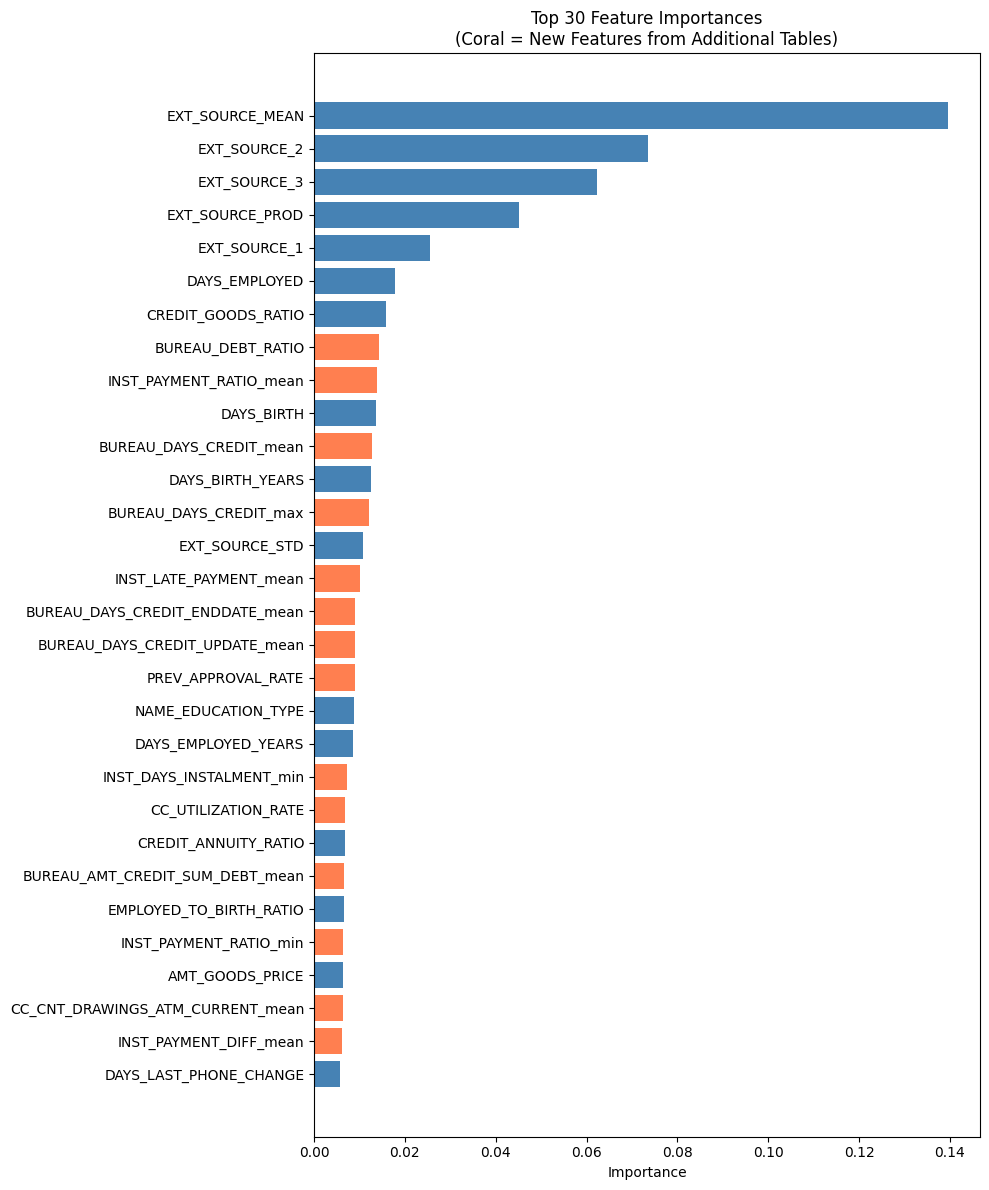

In [ ]:
# Grafik vaznosti atributa
fig, ax = plt.subplots(figsize=(10, 12))
top_30 = feature_importance.head(30)
colors = ['coral' if 'BUREAU' in f or 'PREV' in f or 'POS' in f or 'CC' in f or 'INST' in f 
          else 'steelblue' for f in top_30['Feature']]
ax.barh(top_30['Feature'], top_30['Importance'], color=colors)
ax.set_xlabel('Vaznost')
ax.set_title('Top 30 najvaznijih atributa\n(Coral = Novi atributi iz dodatnih tabela)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Rezime i analiza poboljsanja

In [ ]:
# Ucitavanje rezultata jednostavnog resenja za poredjenje
simple_best = simple_results.loc[simple_results['ROC-AUC'].idxmax()]
advanced_best = results_df.iloc[0]

print("=" * 80)
print("ANALIZA POBOLJSANJA: JEDNOSTAVNO vs NAPREDNO RESENJE")
print("=" * 80)

print(f"\nPoredjenje atributa:")
print(f"   Jednostavno resenje:   122 atributa (samo glavna tabela)")
print(f"   Napredno resenje:      {X.shape[1]} atributa (sve tabele + inzenjering)")

print(f"\nPoredjenje najboljih modela:")
print(f"   Jednostavno: {simple_best['Model']}")
print(f"   Napredno:    {advanced_best['Model']}")

print(f"\nPoboljsanja metrika:")
roc_improvement = (advanced_best['ROC-AUC'] - simple_best['ROC-AUC']) / simple_best['ROC-AUC'] * 100
recall_improvement = (advanced_best['Recall'] - simple_best['Recall']) / (simple_best['Recall'] + 0.001) * 100

print(f"   ROC-AUC:  {simple_best['ROC-AUC']:.4f} -> {advanced_best['ROC-AUC']:.4f} ({roc_improvement:+.1f}%)")
print(f"   Recall:   {simple_best['Recall']:.4f} -> {advanced_best['Recall']:.4f} ({recall_improvement:+.1f}%)")
print(f"   F1-Score: {simple_best['F1-Score']:.4f} -> {advanced_best['F1-Score']:.4f}")

print(f"\nZakljuci:")
print("   1. Bureau i istorija placanja znacajno poboljsavaju predikciju")
print("   2. Balansiranje klasa drasticno poboljsava Recall (pronalazenje defaultera)")
print("   3. Domenski inzenjering atributa (odnosi, kombinacije) dodaje prediktivnu moc")
print("   4. Spoljni izvori ostaju veoma vazni i sa dodatnim atributima")

print("\nKreirani fajlovi:")
print("   - preprocessed_data/application_advanced_preprocessed.csv")
print("   - models/advanced_*.joblib")
print("   - model_comparison_advanced.csv")
print("   - simple_vs_advanced_comparison.png")
print("=" * 80)

IMPROVEMENT ANALYSIS: SIMPLE vs ADVANCED SOLUTION

📊 Feature Comparison:
   Simple Solution:   122 features (main application only)
   Advanced Solution: 300 features (all tables + engineered)

🏆 Best Model Comparison:
   Simple:   4. Gradient Boosting
   Advanced: 4. Gradient Boosting

📈 Metric Improvements:
   ROC-AUC:  0.7570 → 0.7798 (+3.0%)
   Recall:   0.0207 → 0.0435 (+104.7%)
   F1-Score: 0.0399 → 0.0804

🔑 Key Insights:
   1. Bureau and payment history features significantly improve prediction
   2. Class balancing drastically improves Recall (finding defaulters)
   3. Domain-engineered features (ratios, combinations) add predictive power
   4. External sources remain highly important even with additional features

📁 Files Created:
   - preprocessed_data/application_advanced_preprocessed.csv
   - models/advanced_*.joblib
   - model_comparison_advanced.csv
   - simple_vs_advanced_comparison.png


In [ ]:
# Tabela sumarnog poredjenja
summary = pd.DataFrame({
    'Metrika': ['Atributi', 'Najbolji ROC-AUC', 'Najbolji Recall', 'Najbolji F1-Score', 'Najbolji model'],
    'Jednostavno resenje': [122, f"{simple_best['ROC-AUC']:.4f}", f"{simple_best['Recall']:.4f}", 
                        f"{simple_best['F1-Score']:.4f}", simple_best['Model'].split('. ')[1]],
    'Napredno resenje': [X.shape[1], f"{advanced_best['ROC-AUC']:.4f}", f"{advanced_best['Recall']:.4f}",
                          f"{advanced_best['F1-Score']:.4f}", advanced_best['Model'].split('. ')[1]]
})

print("\nTabela sumarnog poredjenja:")
print(summary.to_string(index=False))

summary.to_csv('solution_comparison_summary.csv', index=False)


Summary Comparison Table:
       Metric   Simple Solution Advanced Solution
     Features               122               300
 Best ROC-AUC            0.7570            0.7798
  Best Recall            0.0207            0.0435
Best F1-Score            0.0399            0.0804
   Best Model Gradient Boosting Gradient Boosting


In [ ]:
# Lista svih sacuvanih modela
print("\nSvi sacuvani modeli:")
for f in sorted(os.listdir('models')):
    if 'advanced' in f:
        print(f"  - {f}")


All Saved Models:
  ✅ advanced_1_Logistic_Regression.joblib
  ✅ advanced_2_Decision_Tree.joblib
  ✅ advanced_3_Random_Forest.joblib
  ✅ advanced_4_Gradient_Boosting.joblib
  ✅ advanced_5_K-Nearest_Neighbors.joblib
  ✅ advanced_6_Naive_Bayes.joblib
  ✅ advanced_7_AdaBoost.joblib
  ✅ scaler_advanced.joblib
